<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim



### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

### Datos
Utilizaremos como dataset canciones de bandas de habla inglesa.

In [2]:
# Descargar la carpeta de dataset
import os
import platform
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        if platform.system() in ['Windows', 'Darwin']:
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    !unzip -q songs_dataset.zip
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [3]:
# Posibles bandas
os.listdir("./songs_dataset/")

['prince.txt',
 'dickinson.txt',
 'notorious-big.txt',
 'beatles.txt',
 'bob-dylan.txt',
 'bjork.txt',
 'johnny-cash.txt',
 'disney.txt',
 'janisjoplin.txt',
 'kanye.txt',
 'bob-marley.txt',
 'leonard-cohen.txt',
 'ludacris.txt',
 'adele.txt',
 'alicia-keys.txt',
 'joni-mitchell.txt',
 'amy-winehouse.txt',
 'lorde.txt',
 'rihanna.txt',
 'Kanye_West.txt',
 'nirvana.txt',
 'cake.txt',
 'bieber.txt',
 'notorious_big.txt',
 'missy-elliott.txt',
 'dolly-parton.txt',
 'jimi-hendrix.txt',
 'michael-jackson.txt',
 'al-green.txt',
 'lil-wayne.txt',
 'lady-gaga.txt',
 'lin-manuel-miranda.txt',
 'nursery_rhymes.txt',
 'dj-khaled.txt',
 'radiohead.txt',
 'patti-smith.txt',
 'blink-182.txt',
 'Lil_Wayne.txt',
 'dr-seuss.txt',
 'r-kelly.txt',
 'drake.txt',
 'britney-spears.txt',
 'bruce-springsteen.txt',
 'nicki-minaj.txt',
 'kanye-west.txt',
 'paul-simon.txt',
 'nickelback.txt',
 'eminem.txt',
 'bruno-mars.txt']

In [4]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)
df.head()

/var/folders/p9/d9dgkr4s4dvf55y6w29rn_4w0000gn/T/ipykernel_40389/3849064916.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)


,0
0,"Yesterday, all my troubles seemed so far away"
1,Now it looks as though they're here to stay
2,"Oh, I believe in yesterday Suddenly, I'm not h..."
3,There's a shadow hanging over me.
4,"Oh, yesterday came suddenly Why she had to go ..."


In [5]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 1846


### 1 - Preprocesamiento

In [6]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [7]:
# Demos un vistazo
sentence_tokens[:2]

[['yesterday', 'all', 'my', 'troubles', 'seemed', 'so', 'far', 'away'],
 ['now', 'it', 'looks', 'as', 'though', "they're", 'here', 'to', 'stay']]

### 2 - Crear los vectores (word2vec)

In [8]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [9]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [10]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [11]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 1846


In [12]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 445


### 3 - Entrenar embeddings

In [13]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 113045.28125
Loss after epoch 1: 65966.59375
Loss after epoch 2: 65934.921875
Loss after epoch 3: 65718.390625
Loss after epoch 4: 63875.125
Loss after epoch 5: 64160.90625
Loss after epoch 6: 64080.375
Loss after epoch 7: 64814.96875
Loss after epoch 8: 62632.6875
Loss after epoch 9: 60452.6875
Loss after epoch 10: 59840.125
Loss after epoch 11: 58884.0625
Loss after epoch 12: 57716.0625
Loss after epoch 13: 56493.875
Loss after epoch 14: 55817.5
Loss after epoch 15: 55842.9375
Loss after epoch 16: 51722.625
Loss after epoch 17: 49858.125
Loss after epoch 18: 49592.0
Loss after epoch 19: 48960.375


(156986, 287740)

### 4 - Ensayar

In [14]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["darling"], topn=10)

[('pretty', 0.8954241275787354),
 ('sleep', 0.8665648102760315),
 ('help', 0.8439377546310425),
 ('cry', 0.8351278305053711),
 ('not', 0.8309565782546997),
 ('try', 0.8276928067207336),
 ('peace', 0.8144847750663757),
 ('little', 0.8140541911125183),
 ('twist', 0.8123903870582581),
 ('seems', 0.8079550862312317)]

In [15]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["love"], topn=10)

[('shake', -0.22872473299503326),
 ('four', -0.2330225110054016),
 ('five', -0.23746483027935028),
 ('six', -0.23784109950065613),
 ('bang', -0.24832148849964142),
 ('our', -0.25538331270217896),
 ('day', -0.2689809501171112),
 ('going', -0.26920315623283386),
 ('here', -0.2699021100997925),
 ('three', -0.28389549255371094)]

In [16]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["four"], topn=10)

[('five', 0.9813734292984009),
 ('three', 0.9745770692825317),
 ('six', 0.9710827469825745),
 ('seven', 0.9584391713142395),
 ('two', 0.9517229795455933),
 ('sixty', 0.8990437388420105),
 ('one', 0.7951188087463379),
 ('crying', 0.7946332693099976),
 ('us', 0.7740050554275513),
 ("i'm", 0.7508416175842285)]

In [17]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["money"], topn=5)

[("can't", 0.9434012770652771),
 ('buy', 0.9397005438804626),
 ('much', 0.9033158421516418),
 ('just', 0.8509080410003662),
 ('hide', 0.8355337381362915)]

In [18]:
# Ensayar con una palabra que no está en el vocabulario:
#w2v_model.wv.most_similar(negative=["diedaa"])

In [19]:
# el método `get_vector` permite obtener los vectores:
vector_love = w2v_model.wv.get_vector("love")
print(vector_love)

[ 0.06138405  0.058809   -0.06370325  0.02445593 -0.20152055 -0.18612228
 -0.15284562  0.45487782 -0.04217936  0.03536211  0.13657948 -0.18519847
 -0.18126771  0.2214913  -0.3038063  -0.23970455  0.07094643 -0.05679133
 -0.05166036 -0.23843044 -0.08529771  0.195644   -0.07679128  0.03796851
  0.07516617 -0.04825819  0.07379003  0.10396867  0.00737886 -0.22764948
 -0.04567026  0.12936729  0.27786148  0.19387393 -0.13509513  0.20856662
  0.40916505 -0.00386539 -0.10631859 -0.09057057  0.02400651 -0.08005195
  0.1340099   0.08833113 -0.01894911  0.08592594 -0.15906131  0.10259284
  0.14459819 -0.12092229 -0.279187   -0.0406201   0.11382356  0.31366625
 -0.07409906  0.13977523  0.22791535  0.13209976 -0.01811203  0.0977301
  0.09249622 -0.14872141 -0.16348357 -0.13202755 -0.09834751  0.02714126
  0.16531599  0.26052776 -0.03259096 -0.02894498  0.11620875 -0.06974296
  0.09563834 -0.15276456  0.22071241  0.1599668   0.15890227 -0.04711496
 -0.12555523 -0.03993179 -0.10795247  0.01879167  0.

In [20]:
# el método `most_similar` también permite comparar a partir de vectores
w2v_model.wv.most_similar(vector_love)

[('love', 0.9999999403953552),
 ('babe', 0.9085148572921753),
 ('someone', 0.8886125683784485),
 ('need', 0.8827983736991882),
 ('nothing', 0.8740253448486328),
 ("didn't", 0.8638355135917664),
 ("there's", 0.8526684641838074),
 ('you', 0.8456717729568481),
 ('feed', 0.8445045351982117),
 ('somebody', 0.8362783193588257)]

In [21]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["love"], topn=10)

[('babe', 0.9085148572921753),
 ('someone', 0.8886125683784485),
 ('need', 0.8827983736991882),
 ('nothing', 0.8740253448486328),
 ("didn't", 0.8638355135917664),
 ("there's", 0.8526684641838074),
 ('you', 0.8456718921661377),
 ('feed', 0.8445045351982117),
 ('somebody', 0.8362783193588257),
 ('buy', 0.8351733088493347)]

### 5 - Visualizar agrupación de vectores

In [22]:
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, num_dimensions = 2 ):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [ ]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
#fig.show() # esto para plotly en local
fig.show(renderer="colab") # esto para plotly en colab

In [ ]:
# Graficar los embedddings en 3D

vecs, labels = reduce_dimensions(w2v_model,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
#fig.show() # esto para plotly en local
fig.show(renderer="colab") # esto para plotly en colab

In [25]:
# También se pueden guardar los vectores y labels como tsv para graficar en
# http://projector.tensorflow.org/


vectors = np.asarray(w2v_model.wv.vectors)
labels = list(w2v_model.wv.index_to_key)

np.savetxt("vectors.tsv", vectors, delimiter="\t")

with open("labels.tsv", "w") as fp:
    for item in labels:
        fp.write("%s\n" % item)

### Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

- Crear sus propios vectores con Gensim basado en lo visto en clase con otro artista del dataset Songs.
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

### Vectorización
- Se lee el documento con las letras de Radiohead
- Se tokenizan las oraciones
- Instanciamos el modelo con, frecuencia mínima de 5, window del contexto de 3 palabras antes y despues, tamaño del vector de 400, el modelo elegido es de skipgram
- Se entrena el modelo durante 30 epocas

In [26]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/radiohead.txt', sep='/n', header=None)
df.head()

/var/folders/p9/d9dgkr4s4dvf55y6w29rn_4w0000gn/T/ipykernel_40389/2728444896.py:2: ParserWarning:

Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.



,0
0,"Come on, come on"
1,You think you drive me crazy
2,"Come on, come on"
3,You and whose army?
4,You and your cronies


In [27]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 2343


In [28]:
sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

sentence_tokens[:2]

[['come', 'on', 'come', 'on'], ['you', 'think', 'you', 'drive', 'me', 'crazy']]

In [29]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=3,       # cant de palabras antes y desp de la predicha
                     vector_size=400,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [30]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de docs en el corpus: 2343
Cantidad de words distintas en el corpus: 383


In [31]:
w2v_model.train(
    sentence_tokens,
    total_examples=w2v_model.corpus_count,
    epochs=30,
    compute_loss = True,
    callbacks=[callback()]
)

Loss after epoch 0: 93293.8671875
Loss after epoch 1: 45568.8359375
Loss after epoch 2: 43507.84375
Loss after epoch 3: 42737.578125
Loss after epoch 4: 43801.84375
Loss after epoch 5: 43516.625
Loss after epoch 6: 41546.84375
Loss after epoch 7: 41557.46875
Loss after epoch 8: 41467.09375
Loss after epoch 9: 40309.5
Loss after epoch 10: 39567.71875
Loss after epoch 11: 38840.53125
Loss after epoch 12: 37232.9375
Loss after epoch 13: 36895.875
Loss after epoch 14: 36192.0
Loss after epoch 15: 35412.625
Loss after epoch 16: 34868.1875
Loss after epoch 17: 34281.625
Loss after epoch 18: 34248.5
Loss after epoch 19: 34055.0
Loss after epoch 20: 33933.875
Loss after epoch 21: 32406.875
Loss after epoch 22: 31932.375
Loss after epoch 23: 32413.0625
Loss after epoch 24: 31870.5625
Loss after epoch 25: 31899.75
Loss after epoch 26: 30671.75
Loss after epoch 27: 29891.0
Loss after epoch 28: 29211.125
Loss after epoch 29: 28509.75


(175435, 354090)

### Ejemplos de similitud

In [ ]:
# Palabras que MÁS se relacionan con head:
w2v_model.wv.most_similar(positive=["head"], topn=10)

[('fast', 0.9562258124351501),
 ('feed', 0.9455336928367615),
 ('listen', 0.92421555519104),
 ('mouth', 0.9238340258598328),
 ('breathing', 0.9231318235397339),
 ('life', 0.9135855436325073),
 ('his', 0.9095385074615479),
 ('alarm', 0.9047330021858215),
 ('hand', 0.8990870714187622),
 ('heart', 0.8973697423934937)]

Las palabras más similares a "head" son "fast" y "feed". Aunque semánticamente no parecen relacionadas, esto se explica por el principio fundamental de Skip-gram: el modelo aprende que palabras que aparecen en contextos similares deben tener representaciones vectoriales cercanas. En el corpus se repite la frase "Just to feed your fast ballooning head", lo que genera co-ocurrencias frecuentes entre estas palabras dentro de la ventana de contexto (window=3).

También aparecen palabras como "mouth", "breathing", "hand" y "heart", que sí tienen una relación semántica más evidente con "head" (partes del cuerpo, acciones físicas). Esto sugiere que el modelo captura tanto relaciones contextuales locales (por co-ocurrencia en frases específicas) como relaciones semánticas más generales.

La palabra "listen" probablemente aparece relacionada por ser parte del contexto inmediato de frases que contienen "head", lo que refuerza que Skip-gram no distingue entre relaciones sintácticas, semánticas o puramente co-ocurrentes.

In [72]:
# Palabras que MÁS se relacionan con dinosaurs:
w2v_model.wv.most_similar(positive=["dinosaurs"], topn=10)

[('earth', 0.9927560091018677),
 ('clear', 0.9833807349205017),
 ('burn', 0.9785874485969543),
 ('eye', 0.9785507321357727),
 ('town', 0.9686375260353088),
 ('innocent', 0.9684550762176514),
 ('goes', 0.967014491558075),
 ('sea', 0.9649387001991272),
 ('hole', 0.96418297290802),
 ('sleep', 0.9626659154891968)]

Se selecciona una palabra con menor frecuencia de aparición para observar cómo el modelo maneja casos con menos ejemplos de entrenamiento. La palabra más similar a "dinosaurs" es "earth" con un score muy alto (0.99), lo cual se explica por las frases "dinosaurs roam the earth" y "Dinosaurs roaming the Earth" presentes en el corpus.

Es importante notar que palabras como "roam" y "roaming" no aparecen en el vocabulario porque no alcanzan la frecuencia mínima (min_count=5). Esto ilustra una limitación del modelo: palabras poco frecuentes quedan excluidas, aunque sean semánticamente relevantes. Esto se podría evitar si se pudiera tokenizar la raíz de la palabra, en ese caso sí sería probable que aparezca como la más similar.

Las otras palabras similares ("clear", "burn", "eye", "sea", "innocent") no tienen relación semántica directa con "dinosaurs", pero comparten contextos de aparición similares en el corpus. Esto demuestra que Word2Vec con Skip-gram captura relaciones distribucionales (basadas en co-ocurrencia) y no relaciones conceptuales o de conocimiento del mundo.

In [78]:
# Palabras que MÁS se relacionan con dark:
w2v_model.wv.most_similar(positive=["dark"], topn=10)

[('last', 0.9585110545158386),
 ('clear', 0.9578898549079895),
 ('hit', 0.9566305875778198),
 ('bottom', 0.9559773206710815),
 ('hole', 0.946367621421814),
 ("they're", 0.9459713697433472),
 ('innocent', 0.9417847394943237),
 ('burn', 0.9408000111579895),
 ('alarm', 0.9406805634498596),
 ('hour', 0.9398883581161499)]

In [82]:
# Palabras que MÁS se relacionan con hate:
w2v_model.wv.most_similar(positive=["always"], topn=10)

[('ever', 0.9175565838813782),
 ('thing', 0.9151651263237),
 ('gone', 0.9142825603485107),
 ('real', 0.9126338958740234),
 ('goes', 0.9123029708862305),
 ("what's", 0.9063910245895386),
 ('late', 0.9010326862335205),
 ('another', 0.8995329141616821),
 ('song', 0.8983715176582336),
 ("it's", 0.8956665396690369)]

Al buscar palabras similares a "always", encontramos "ever", "gone", "real", entre otras. "Ever" tiene sentido como resultado ya que comparte contextos sintácticos similares ("always thinking" vs "ever thinking").

Un fenómeno interesante de Word2Vec es que los antónimos suelen tener vectores similares, no opuestos. Esto ocurre porque antónimos como "always"/"never", "good"/"bad", "love"/"hate" aparecen en los mismos contextos gramaticales:
- "I always think about you" vs "I never think about you"
- "This is good" vs "This is bad"

Esta es una limitación de los modelos basados en distribución: no pueden distinguir entre sinónimos y antónimos porque ambos comparten patrones de co-ocurrencia similares.

In [74]:
# Palabras que MENOS se relacionan con dinosaurs:
w2v_model.wv.most_similar(negative=["good"], topn=10)

[('uptight', -0.02196653001010418),
 ('wears', -0.18921531736850739),
 ('arms', -0.2142428457736969),
 ('out', -0.22639520466327667),
 ('let', -0.23200388252735138),
 ('reach', -0.2331097424030304),
 ('inside', -0.24381355941295624),
 ('hearts', -0.2458067685365677),
 ('broken', -0.25005775690078735),
 ('fade', -0.25097545981407166)]

In [ ]:
# Palabras que MENOS se relacionan con dark:
w2v_model.wv.most_similar(negative=["dark"], topn=10)

[('uptight', 0.005743814632296562),
 ('yourself', -0.4801667630672455),
 ('do', -0.4944404363632202),
 ('want', -0.5116674900054932),
 ('it', -0.5218226313591003),
 ('really', -0.528642475605011),
 ('what', -0.5328812003135681),
 ('run', -0.5403985977172852),
 ('dream', -0.5440309047698975),
 ('where', -0.544638991355896)]

In [ ]:
# Palabras que MENOS se relacionan con clear:
w2v_model.wv.most_similar(negative=["clear"], topn=10)

[('uptight', -0.00641860393807292),
 ('do', -0.5620748400688171),
 ('yourself', -0.5669358372688293),
 ('you', -0.5712540745735168),
 ('bit', -0.5734673738479614),
 ('want', -0.5764467120170593),
 ('should', -0.5838174223899841),
 ('run', -0.5853961706161499),
 ('i', -0.5874369144439697),
 ("don't", -0.5916438698768616)]

La palabra "uptight" aparece consistentemente como la menos relacionada con prácticamente cualquier término. Esto indica que tiene un contexto de uso muy particular y aislado en el corpus, lo que la ubica en una región del espacio vectorial alejada del resto.

Cuando se buscan palabras con menor similitud coseno se buscan vectores que apuntan en direcciones diferentes:
- Alta similitud coseno: contextos de uso similares (no necesariamente sinónimos)
- Baja similitud coseno: contextos de uso completamente diferentes (no significa opuesto semántico)

Por esta razón, las palabras "menos relacionadas" no tienen relación semántica de oposición con la palabra de consulta. Simplemente aparecen en contextos completamente distintos dentro del corpus. Los antónimos, paradójicamente, suelen tener alta similitud porque comparten estructuras sintácticas.

### Visualización en 2D

In [ ]:
_vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=383
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
#fig.show() 
fig.show(renderer="colab") # esto para plotly en colab

### Análisis de la visualización de embeddings

La reducción de dimensionalidad mediante t-SNE permite visualizar los embeddings de 400 dimensiones en un plano 2D. Es importante recordar que t-SNE prioriza preservar las distancias locales, por lo que los clusters cercanos son más confiables que las distancias globales.

Observaciones del gráfico:

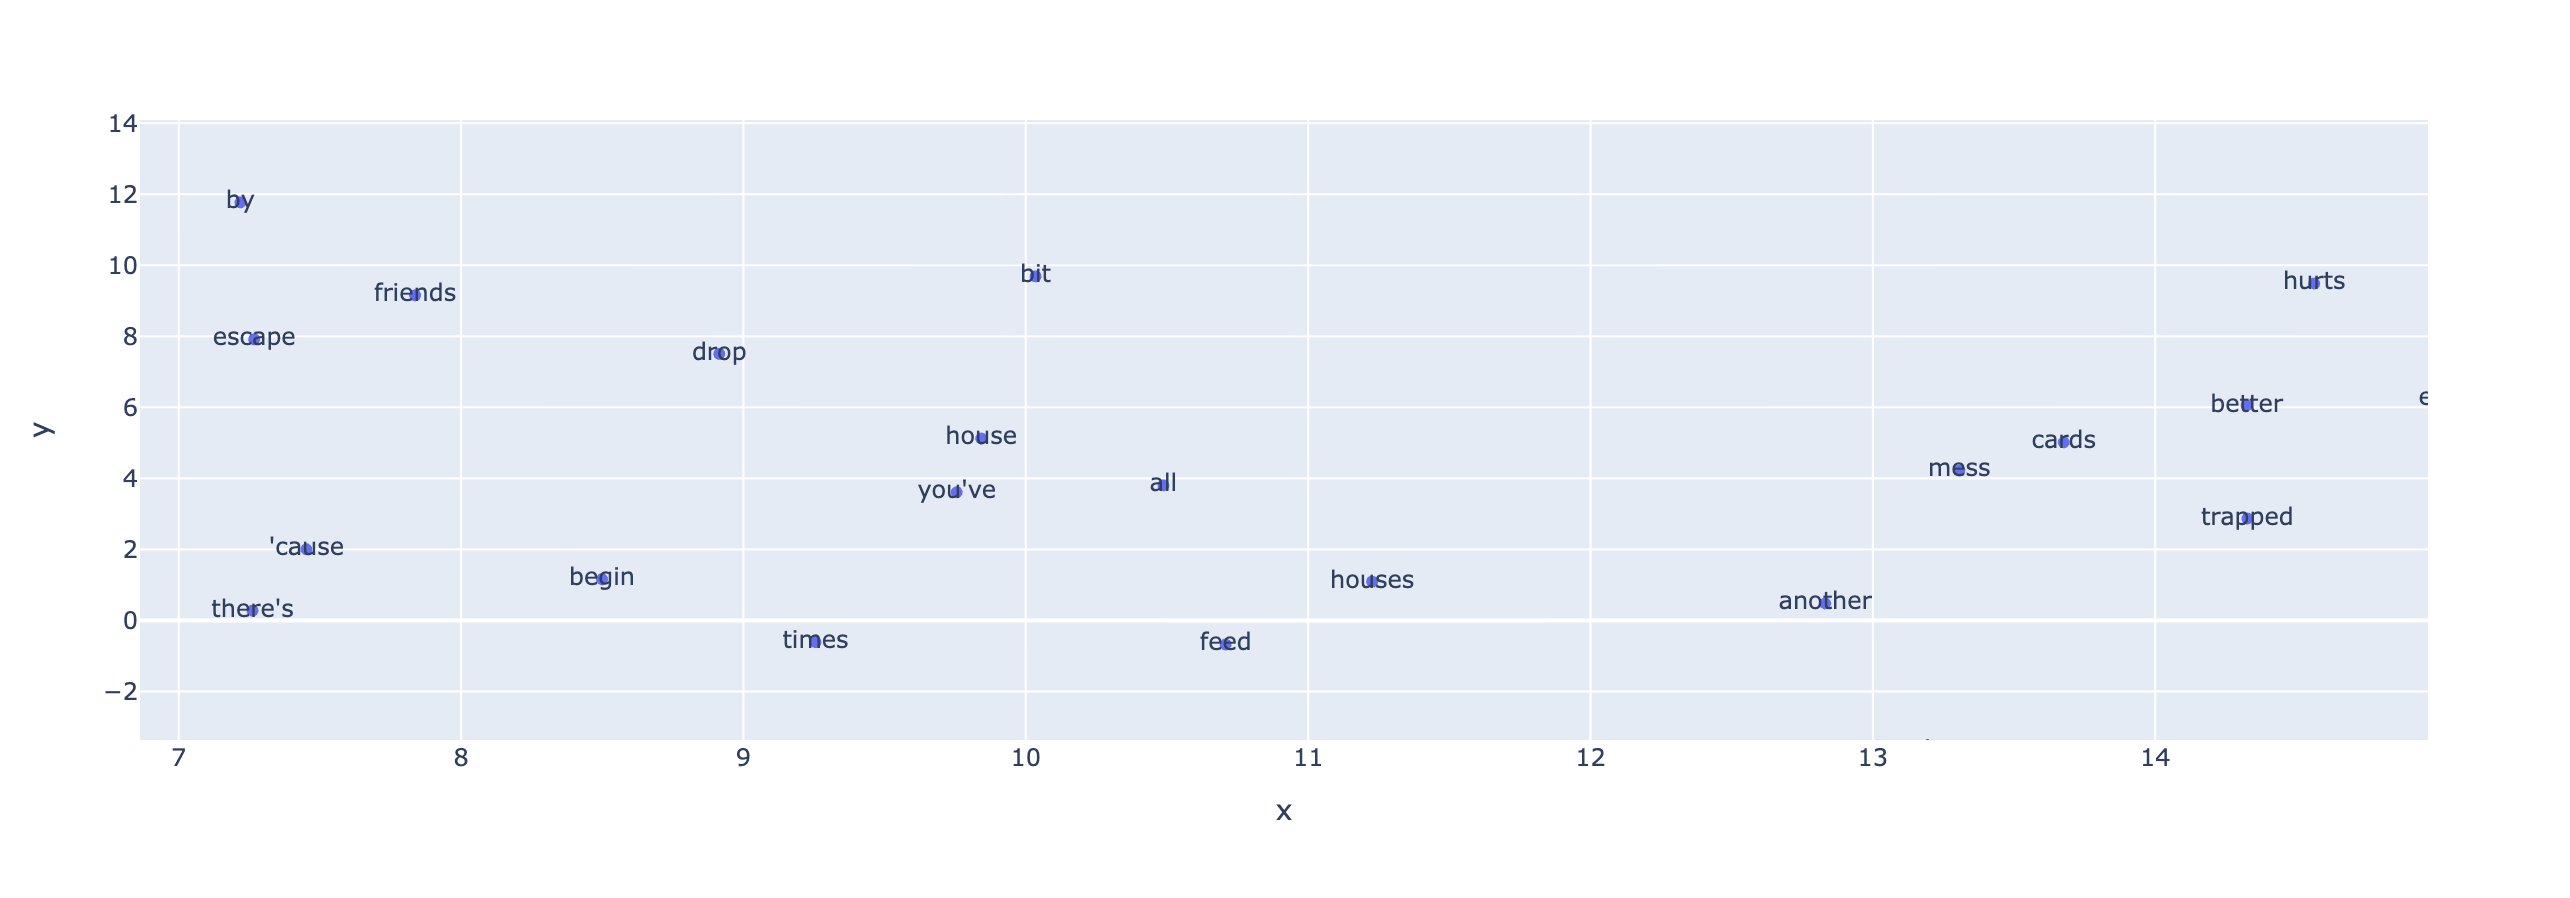

En este ejemplo se observa como la palabra "house" y "houses" se encuentran muy cerca, lo que tiene mucho sentido. También se ve que la palabra "cards" está cerca y esto se debe a su co-ocurrencia en la canción llamada "House of cards".

"Bit" y "all" también se encuentran cerca, son cuantificadores que comparten estructuras sintácticas similares ("a bit of...", "all of...") y de ahí su similitud.

La palabra "feed" también está cerca de la palabra "drop", buscando en el corpus se observa que se encuentra cerca de la palabra "drip", que puede tener un sentido similar a "drop" y tener contextos similares, de ahí su cercanía.

En la zona derecha se observan palabras como "trapped", "hurts", "better" y "mess" agrupadas, todas con carga emocional negativa, algo típico de las letras de Radiohead.

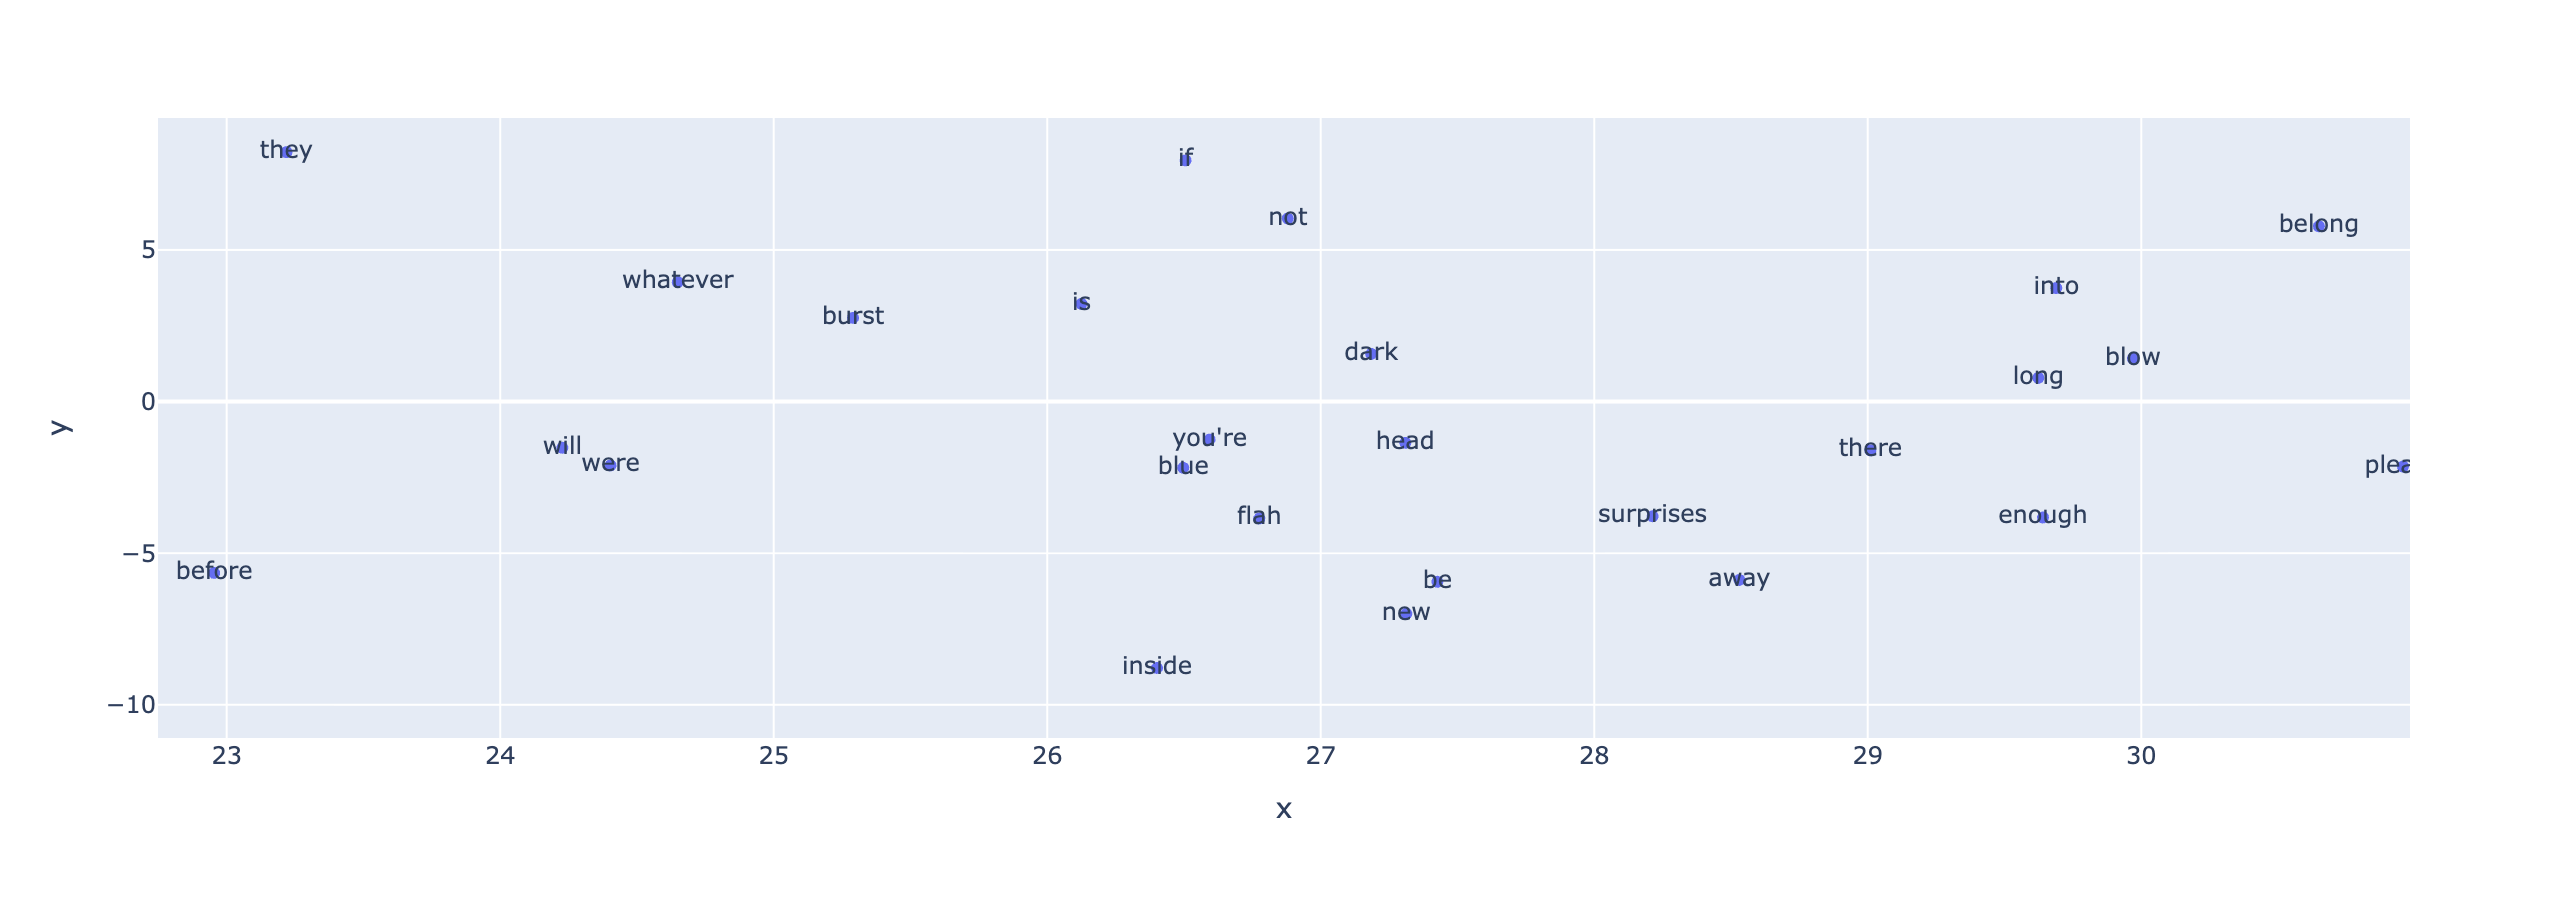

En este otro ejemplo se ven palabras como "new" y "surprises", "burst" y "blow", "if" y "not", "dark" y "blue", que son todas palabras muy relacionadas o de uso conjunto común.

También se observa que "will" y "were" están juntas, ambas son verbos auxiliares que comparten contextos gramaticales.

En la zona superior derecha aparecen "giant", "big" y "hanging", palabras descriptivas de tamaño o posición física.

Abajo a la derecha se agrupan "dream", "believe" y "please", verbos relacionados con deseos o peticiones.

Finalmente, "some" y "eyes" aparecen muy cerca abajo a la izquierda, probablemente por frases del tipo "some eyes" en el corpus.

### Conclusiones

El modelo Word2Vec con Skip-gram entrenado sobre letras de Radiohead permite observar cómo las representaciones vectoriales capturan relaciones basadas en co-ocurrencia y no en semántica pura.

Las principales observaciones son:
- Palabras que aparecen juntas frecuentemente en el corpus obtienen vectores similares, aunque no tengan relación semántica evidente (ej: "head", "fast", "feed").
- El modelo agrupa correctamente palabras con relaciones semánticas cuando estas también comparten contextos (partes del cuerpo, números, verbos auxiliares).
- Los antónimos tienden a tener vectores similares porque aparecen en estructuras gramaticales equivalentes.
- La búsqueda de palabras "menos similares" no devuelve antónimos sino palabras con contextos de uso completamente diferentes.
- Palabras con uso muy específico o aislado, como "uptight", quedan en regiones apartadas del espacio vectorial.

Estas observaciones refuerzan la idea de que Word2Vec es un modelo distribucional: aprende de cómo se usan las palabras, no de qué significan.